# Backtest with `CSVDataSource`

This notebook backtests a strategy against real historical tick data. It streams
ticks straight from the Polygon.IO quote archives in `data/quotes/`, runs the
task with the server's `TaskManager`, and summarizes the strategy events it
produced.

The archives (`*.csv.gz`) hold one row per quote across *all* instruments — tens
of millions of rows per daily file. Given a Polygon tick schema,
`core.CSVDataSource` filters rows by ticker *before* validating them and streams
sequentially across the files, so no intermediate per-instrument file is
written. The data is processed lazily as the backtest runs.

The pieces come from the workspace packages:

- **`core`** — domain models, `CSVDataSource`, and `BacktestTaskDefinition`.
- **`auto_forex_server`** — `TaskManager`, the in-memory repository, and the
  event bus that runs the backtest in the background.
- **`notebooks`** — an example moving-average crossover strategy (real
  strategies live in `snowball`).

In [1]:
from pathlib import Path

import pandas as pd
from auto_forex_server import EventBus, InMemoryTaskRepository, RecordingEventHandler
from auto_forex_server.tasks import TaskManager
from core import (
    BacktestTaskDefinition,
    CSVDataSource,
    CSVTickSchema,
    CurrencyPair,
    LogLevel,
    StrategyEvent,
    configure_logging,
)

from notebooks import MovingAverageCrossStrategy

configure_logging(level=LogLevel.WARNING)

<Logger core (WARNING)>

## 1. Point the data source at the quote archives

`CSVDataSource.from_directory` discovers the daily `*.csv.gz` archives in
`data/quotes/` and reads them in chronological order. Nothing is loaded yet —
ticks are streamed lazily when the backtest iterates them.

In [2]:
INSTRUMENT = CurrencyPair.of("EUR_USD")
QUOTES_DIR = Path("data") / "quotes"

# Polygon forex quote archives hold every instrument per row. The schema tells
# CSVDataSource which columns to read, and it filters by ticker before parsing,
# so only EUR_USD rows are validated as it streams the daily files in order.
data_source = CSVDataSource.from_directory(
    QUOTES_DIR,
    tick_pattern="*.csv.gz",
    tick_schema=CSVTickSchema.polygon_forex_quotes(),
)

print(f"Streaming {INSTRUMENT} from:")
for archive in data_source.tick_paths:
    print(f"  {archive.name}")

Streaming EUR_USD from:
  2026-06-23.csv.gz
  2026-06-24.csv.gz
  2026-06-25.csv.gz
  2026-06-26.csv.gz


In [3]:
# Derive the backtest window from the archive filenames (YYYY-MM-DD per day),
# rather than scanning the data. The window is timezone-aware and inclusive of
# the last day. Adjust start_at/end_at to backtest a narrower slice.
from datetime import UTC, datetime, timedelta

archive_days = sorted(
    datetime.strptime(path.name.split(".", 1)[0], "%Y-%m-%d").replace(tzinfo=UTC)
    for path in data_source.tick_paths
)
start_at = archive_days[0]
end_at = archive_days[-1] + timedelta(days=1)
print(f"Backtest window: {start_at} -> {end_at}")

Backtest window: 2026-06-23 00:00:00+00:00 -> 2026-06-27 00:00:00+00:00


## 2. Define the backtest task and strategy

A `BacktestTaskDefinition` describes *what* to run — instrument, parameters,
time window, initial balance. It deliberately does **not** name a strategy or a
data source; those are supplied to `TaskManager.start_backtest` as live objects.

In [4]:
# Moving-average periods are in ticks. On dense tick data the small defaults
# (5/20) are noisy, so use longer windows for this backtest.
parameters = MovingAverageCrossStrategy.default_parameters().merge(
    {"fast_period": 100, "slow_period": 500, "units": 1000}
)

definition = BacktestTaskDefinition(
    name=f"{INSTRUMENT} MA crossover demo",
    instrument=INSTRUMENT,
    start_at=start_at,
    end_at=end_at,
    parameters=parameters,
)
definition.dump()

{'id': UUID('019f1011-6b46-716a-a168-477fabdffb3a'),
 'name': 'EUR_USD MA crossover demo',
 'instrument': {'base': {'code': 'EUR'}, 'quote': {'code': 'USD'}},
 'parameters': {'values': {'fast_period': 100,
   'slow_period': 500,
   'units': 1000}},
 'created_at': datetime.datetime(2026, 6, 28, 21, 10, 4, 870609, tzinfo=datetime.timezone.utc),
 'task_type': <TaskType.BACKTEST: 'backtest'>,
 'start_at': datetime.datetime(2026, 6, 23, 0, 0, tzinfo=datetime.timezone.utc),
 'end_at': datetime.datetime(2026, 6, 27, 0, 0, tzinfo=datetime.timezone.utc),
 'initial_balance': {'amount': Decimal('10000'), 'currency': {'code': 'USD'}}}

In [5]:
strategy = MovingAverageCrossStrategy(
    name="ma_cross",
    parameters=definition.parameters,
)
strategy

## 3. Run the backtest

`TaskManager.start_backtest` launches a `BacktestRunner` on a background
thread. A `RecordingEventHandler` subscribed to the event bus captures every
event the run publishes; `manager.wait` blocks until the run finishes.

In [6]:
recorder = RecordingEventHandler()
event_bus = EventBus(handlers=[recorder])
manager = TaskManager(repository=InMemoryTaskRepository(), event_bus=event_bus)

# The source scans every row of each daily archive (hundreds of millions of
# rows total) to stream this instrument, so allow a few minutes.
task = manager.start_backtest(definition, data_source=data_source, strategy=strategy)
final_task = manager.wait(task.id, timeout=600)
manager.shutdown()

print(f"Task {final_task.id} finished with status: {final_task.status.value}")
print(f"Events recorded: {len(recorder.events)}")

Task 019f1011-6b4e-7684-800e-24c0e47b41a2 finished with status: completed
Events recorded: 2547


## 4. Inspect the results

Pull the strategy signals out of the recorded events and load them into a
DataFrame for analysis.

In [7]:
signals = [event for event in recorder.events if isinstance(event, StrategyEvent)]

signals_df = pd.DataFrame(
    {
        "timestamp": event.timestamp,
        "action": event.action.value,
        "side": event.side.value if event.side else None,
        "units": float(event.units) if event.units is not None else None,
        "price": float(event.price.amount) if event.price is not None else None,
        "decision": event.reason.code.value,
    }
    for event in signals
)
print(f"{len(signals_df)} strategy signals")
signals_df

2545 strategy signals


,timestamp,action,side,units,price,decision
0,2026-06-28 21:10:17.901908+00:00,open_position,buy,1000.0,1.142560,entry_signal
1,2026-06-28 21:10:17.908872+00:00,close_position,NaN,NaN,1.142525,exit_signal
2,2026-06-28 21:10:17.918818+00:00,open_position,buy,1000.0,1.142575,entry_signal
3,2026-06-28 21:10:17.931948+00:00,close_position,NaN,NaN,1.142530,exit_signal
4,2026-06-28 21:10:17.976294+00:00,open_position,buy,1000.0,1.142395,entry_signal
...,...,...,...,...,...,...
2540,2026-06-28 21:13:01.626702+00:00,open_position,buy,1000.0,1.138665,entry_signal
2541,2026-06-28 21:13:01.650857+00:00,close_position,NaN,NaN,1.138555,exit_signal
2542,2026-06-28 21:13:01.658809+00:00,open_position,buy,1000.0,1.138700,entry_signal
2543,2026-06-28 21:13:01.664760+00:00,close_position,NaN,NaN,1.138605,exit_signal


In [8]:
signals_df["action"].value_counts() if not signals_df.empty else "no signals"

action
open_position     1273
close_position    1272
Name: count, dtype: int64

<Axes: title={'center': 'EUR_USD signal prices'}, xlabel='time', ylabel='price (USD)'>

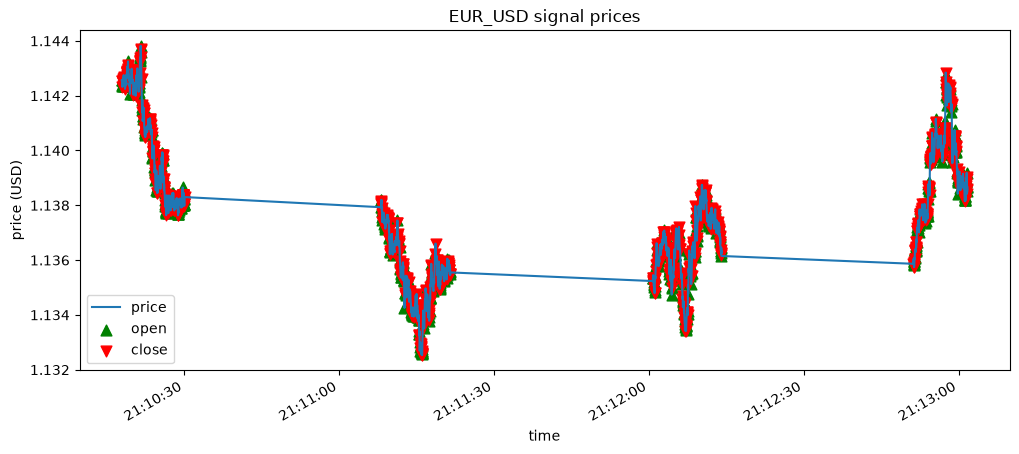

In [9]:
# Plot the signal prices over time with entry/exit markers. The prices come
# from the recorded strategy events, so no tick data is re-read here.
import matplotlib.dates as mdates


def plot_signals(signals: pd.DataFrame):
    """Plot recorded signal prices with entry/exit markers."""
    if signals.empty:
        print("no signals to plot")
        return None
    times = pd.to_datetime(signals["timestamp"]).dt.tz_localize(None)
    marker_times = mdates.date2num(times)
    entries = (signals["action"] == "open_position").to_numpy()
    exits = (signals["action"] == "close_position").to_numpy()
    prices_arr = signals["price"].to_numpy()

    ax = signals.assign(t=times).plot(
        x="t", y="price", figsize=(12, 5), legend=False, title=f"{INSTRUMENT} signal prices"
    )
    ax.scatter(
        marker_times[entries], prices_arr[entries], marker="^", color="green", s=60, label="open"
    )
    ax.scatter(marker_times[exits], prices_arr[exits], marker="v", color="red", s=60, label="close")
    ax.set_xlabel("time")
    ax.set_ylabel(f"price ({INSTRUMENT.quote})")
    ax.legend()
    return ax


plot_signals(signals_df)

## Next steps

- Backtest a different pair by changing `INSTRUMENT` (e.g.
  `CurrencyPair.of("GBP_USD")`); the source filters the same archives by ticker.
- Narrow the run by overriding `start_at` / `end_at` before building the
  definition.
- Drop additional daily `*.csv.gz` archives into `data/quotes/` to extend the
  date range — `from_directory` reads them in chronological order.
- Replace `MovingAverageCrossStrategy` with a real strategy from `snowball`
  once it is implemented, and register it with `server`'s `StrategyRegistry`.
- Tune `fast_period` / `slow_period` / `units` via the task definition's
  `parameters`.